# Computer Exercise 4.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.1 Polynomial Interpolation — *The Runge phenomenon*
> **풀이 일자**: Day 103
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

---

Problem 1 은 **표현을 바꾸면 무엇이 달라지는가**를 물었고, 답은 *비용은 달라지고 정확도는
절점이 결정한다* 였다. Problem 2 는 그 절점 쪽을 정면으로 본다. 형식을 가장 좋은 것
(무게중심) 으로 **고정해 놓고**, 무한정 매끄러운 함수를 등간격 절점에서 보간하면
**차수를 올릴수록 오차가 커진다.**

## 1. 문제 (원문)

> **Computer Exercise 4.1.2.** Let $f(x)=\dfrac{1}{1+25x^{2}}$ on $[-1,1]$ (Runge's function).
> For $n=4,8,12,\dots$, form the polynomial $p_n$ interpolating $f$ at the $n+1$ equally spaced
> points $x_i=-1+2i/n$, and plot $p_n$ together with $f$. Tabulate $\max_{[-1,1]}|f-p_n|$ as a
> function of $n$ and observe that it *increases* without bound. Repeat the experiment with
> $f(x)=|x|$ and $f(x)=e^{x}$ and explain the different behaviour in each case.
>
> Explain the phenomenon using the interpolation error formula
> $$f(x)-p_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\,\omega(x),\qquad \omega(x)=\prod_{i=0}^{n}(x-x_i),$$
> by examining the size and shape of $\omega$ on $[-1,1]$, and quantify the amplification of data
> error by measuring the Lebesgue constant $\Lambda_n=\max_x\sum_i|\ell_i(x)|$ of the equally
> spaced nodes. Determine, numerically, the set of points at which $p_n\to f$ and compare with the
> classical threshold.

### 한국어 풀이용 정리

세 가지를 잰다.

1. **현상** — Runge 함수 $1/(1+25x^2)$ 를 $[-1,1]$ 등간격 절점에서 보간하면 $n$ 을 올릴수록
   구간 양 끝에서 진동이 커지고 $\max|f-p_n|\to\infty$. 대조군으로 $e^{x}$ (전해석함수, 수렴)
   와 $|x|$ (매끄럽지 않음, Bernstein 1912 에 의해 $x\ne 0,\pm1$ 에서 발산) 를 함께 돌린다.
2. **원인** — 오차식 $f^{(n+1)}(\xi)/(n+1)!\cdot\omega(x)$ 의 두 인자를 따로 본다.
   $\omega$ 는 등간격 절점에서 **끝으로 갈수록 폭발**하고, $f^{(n+1)}/(n+1)!$ 는 Runge 함수의
   복소 극점 $\pm i/5$ 때문에 $5^{n}$ 규모로 커진다. 둘의 곱이 위치에 따라 수렴/발산을 가른다.
3. **정량화** — 위치별 수렴률을 실측해 **퍼텐셜 이론이 예측하는 임계점 $x^\star = 0.7266768\ldots$**
   과 대조하고, 데이터 오차 증폭률인 **Lebesgue 상수**의 $2^{n}$ 급 증가를 측정한다.

## 2. 수학적 배경

### 2.1 보간오차 정리 (§4.2 선취)

$f\in C^{n+1}[a,b]$, $p_n$ 이 $x_0,\dots,x_n$ 에서 $f$ 를 보간하면 각 $x$ 에 대해 어떤 $\xi_x$ 가 있어

$$\boxed{\;f(x)-p_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\;\omega(x),\qquad
\omega(x)=\prod_{i=0}^{n}(x-x_i).\;}$$

오른쪽은 **두 인자의 곱**이고, 각각이 따로 폭발할 수 있다.

* $\omega$ — **절점만의 함수**. $f$ 와 무관하다. 등간격 절점에서 $|\omega|$ 는 구간 중앙에서
  작고 **양 끝 가까이에서 훨씬 크다** (끝 두 절점 사이의 봉우리가 중앙 봉우리의 수백~수만 배).
* $f^{(n+1)}/(n+1)!$ — **함수만의 성질**. Cauchy 부등식에 의해, $f$ 가 $x$ 중심 반지름 $r$ 원판에서
  해석적이고 그 위에서 $|f|\le M_r$ 이면

$$\frac{|f^{(k)}(x)|}{k!}\;\le\;\frac{M_r}{r^{k}}.$$

Runge 함수는 $z=\pm i/5$ 에 극점이 있으므로 실축의 어떤 점에서도 $r<1/5$ 여야 하고, 따라서
$|f^{(n+1)}|/(n+1)!$ 는 대략 $5^{\,n+1}$ 규모로 커진다.

### 2.2 위치별 수렴 조건 — 퍼텐셜 이론

$n\to\infty$ 에서 등간격 절점은 $[-1,1]$ 위의 **균등측도** $d\mu=\tfrac12 dt$ 로 수렴한다.
로그 퍼텐셜

$$u(z)=\int_{-1}^{1}\log|z-t|\,\tfrac{dt}{2}$$

를 쓰면 $\tfrac1n\log|\omega_n(z)|\to u(z)$ 이다. 실수 $x\in(-1,1)$ 에 대해

$$\boxed{\;u(x)=\tfrac12\bigl[(1+x)\log(1+x)+(1-x)\log(1-x)\bigr]-1\;}$$

이고, $f$ 의 가장 가까운 특이점 $z_0$ 에 대해서는 (Runge 의 경우 $z_0=i/5$)

$$u(z_0)=\tfrac14\int_{-1}^{1}\log\!\bigl(t^{2}+\tfrac1{25}\bigr)dt
=\tfrac12\Bigl[\log\tfrac{26}{25}-2+\tfrac25\arctan 5\Bigr].$$

**판정 기준.** 보간 오차는 대략 $\exp\!\bigl[n\,(u(x)-u(z_0))\bigr]$ 처럼 거동하므로

$$\boxed{\;u(x)<u(z_0)\ \Rightarrow\ p_n(x)\to f(x),\qquad
u(x)>u(z_0)\ \Rightarrow\ |p_n(x)|\to\infty. \;}$$

$u$ 는 $|x|$ 의 증가함수이므로 임계점 $x^\star$ 는 $u(x^\star)=u(z_0)$ 의 해이고,
$x^\star = 0.7266768605\ldots$ 이다 (흔히 $\approx 0.7267$ 로 인용된다). 이 노트북은 **$x^\star$ 를 이론에서 풀고, 동시에 실측 수렴률의
부호가 바뀌는 지점으로도 찾아** 둘을 비교한다.

### 2.3 Lebesgue 상수 — 자료 오차의 증폭

$$\Lambda_n=\max_{x\in[a,b]}\sum_{i=0}^{n}|\ell_i(x)|,\qquad
\|\tilde p_n-p_n\|_\infty\le\Lambda_n\|\tilde y-y\|_\infty .$$

또한 **Lebesgue 부등식**이 최선근사 $p^\star_n$ 과 이어 준다:

$$\|f-p_n\|_\infty\le(1+\Lambda_n)\,\|f-p^\star_n\|_\infty=(1+\Lambda_n)\,E_n(f).$$

등간격 절점에서는 (Turetskii 1940)

$$\Lambda_n^{\text{equi}}\ \sim\ \frac{2^{\,n+1}}{e\,n\log n}$$

로 **지수적으로** 커진다. 이는 반올림 오차만으로도 큰 $n$ 에서 보간을 망가뜨린다는 뜻이며,
Problem 1 [a] 에서 이미 그 흔적을 봤다.

### 2.4 세 시험 함수

| $f$ | 특이성 | 등간격 절점에서의 거동 |
|---|---|---|
| $1/(1+25x^2)$ | $z=\pm i/5$ 극점 | $\|x\|>x^\star\approx0.72668$ 에서 발산 |
| $e^{x}$ | 전해석 (특이점 없음, $z_0=\infty$) | $u(z_0)=+\infty$ 이므로 **어디서나 수렴** |
| $\|x\|$ | $x=0$ 에서 미분 불가 | $x\ne0,\pm1$ 에서 발산 (Bernstein 1912) |

## 3. 풀이 흐름

1. **안정한 무게 계산** — 큰 $n$ 에서 곱이 언더/오버플로하지 않도록 무게를 **로그합**으로 만든다
   (무게중심 공식은 무게의 공통 상수배에 불변이므로 정규화해도 무방).
2. **현상 재현** — Runge 함수를 $n=4,8,12,16$ 등간격 절점에서 보간해 $f$ 와 함께 그린다.
3. **최대오차 표** — 세 함수 × $n=2,\dots,40$ (짝수) 에서 $\|f-p_n\|_\infty$ 를 조밀격자로 측정.
4. **위치별 수렴률** — 오차를 **절점 사이 중점(midpoint)** 에서 잰다. 절점 위에서는 오차가
   정의상 0 이므로 격자점을 그냥 찍으면 측정이 무의미해지기 때문이다 (중점은 $|\omega|$ 의 국소
   봉우리이므로 오차의 **포락선**을 준다). 각 $x$ 에서 $\log(\text{envelope error})$ 를
   $n\in[16,40]$ 짝수에 선형적합해 **측정 기울기**를 얻고 이론값 $u(x)-u(z_0)$ 와 겹쳐 그린다.
   기울기의 부호가 바뀌는 지점을 보간해 $x^\star_{\text{meas}}$ 를 얻는다.
   측정이 반올림에 오염되지 않았음은 **`float64` 와 `longdouble`(80-bit) 재계산의 차**로 확인한다.
5. **$\omega$ 의 모양** — $|\omega(x)|$ 를 $n=10,20,30$ 에서 그리고, **중앙 봉우리 대 끝 봉우리
   비**를 표로.
6. **Lebesgue 상수** — $\Lambda_n$ 을 $n$ 에 대해 재고 $2^{n+1}/(e\,n\log n)$ 과의 비를 본다.
7. **시각화** — 6 패널.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  도구 — 로그합 기반 안정 무게 + 무게중심 보간 + 세 시험 함수
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import math

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.set_option("display.width", 200)
eps = np.finfo(float).eps

def bary_weights_log(xn):
    """w_i = 1/prod_{j!=i}(x_i-x_j) 를 로그합으로. 공통 상수배는 무해하므로 정규화한다."""
    xn = np.asarray(xn, float); n1 = xn.size
    D = xn[:, None] - xn[None, :]
    np.fill_diagonal(D, 1.0)
    logs = np.log(np.abs(D)).sum(axis=1)          # log prod |x_i - x_j|
    sign = np.where(((D < 0).sum(axis=1) % 2) == 1, -1.0, 1.0)
    l = -logs; l -= l.max()                       # 정규화
    return sign * np.exp(l)

def bary_eval(xn, yn, w, xe):
    xn = np.asarray(xn, float); yn = np.asarray(yn, float)
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe)
    exact = np.full(xe.shape, -1, dtype=int)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); exact[hit] = i; dx[hit] = 1.0
        t = w[i] / dx
        num += t * yn[i]; den += t
    out = num / den
    m = exact >= 0; out[m] = yn[exact[m]]
    return out

def interp_equi(f, n, xe):
    xn = np.linspace(-1.0, 1.0, n + 1)
    return bary_eval(xn, f(xn), bary_weights_log(xn), xe), xn

def lebesgue(xn, xe):
    w = bary_weights_log(xn)
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe); ex = np.zeros(xe.shape, bool)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); ex |= hit; dx[hit] = 1.0
        t = w[i] / dx
        num += np.abs(t); den += t
    lam = num / np.abs(den); lam[ex] = 1.0
    return lam

f_runge = lambda x: 1.0 / (1.0 + 25.0 * x**2)
f_abs   = lambda x: np.abs(x)
f_exp   = lambda x: np.exp(x)
FUNCS = [("Runge 1/(1+25x^2)", f_runge), ("|x|", f_abs), ("exp(x)", f_exp)]

# --- 로그합 무게가 직접곱 무게와 (상수배로) 같은지 확인 ---
xt = np.linspace(-1, 1, 21)
D = xt[:, None] - xt[None, :]; np.fill_diagonal(D, 1.0)
w_dir = 1.0 / np.prod(D, axis=1); w_log = bary_weights_log(xt)
r = w_dir / w_log
print("무게 계산 검증 (n=20 등간격) : 로그합 무게 / 직접곱 무게 의 비가 상수인가")
print(f"  비의 최대/최소 = {r.max()/r.min():.16f}   (1 이면 정확히 상수배)")
xdd = np.linspace(-1, 1, 501)
p_dir = bary_eval(xt, f_runge(xt), w_dir, xdd)
p_log = bary_eval(xt, f_runge(xt), w_log, xdd)
print(f"  두 무게로 얻은 보간값의 최대 차 = {np.max(np.abs(p_dir-p_log)):.3e}")
print(f"  로그합 무게의 크기 범위 : [{np.abs(w_log).min():.3e}, {np.abs(w_log).max():.3e}]"
      f"  (직접곱은 [{np.abs(w_dir).min():.3e}, {np.abs(w_dir).max():.3e}])")


무게 계산 검증 (n=20 등간격) : 로그합 무게 / 직접곱 무게 의 비가 상수인가
  비의 최대/최소 = 1.0000000000000060   (1 이면 정확히 상수배)
  두 무게로 얻은 보간값의 최대 차 = 5.995e-10
  로그합 무게의 크기 범위 : [5.413e-06, 1.000e+00]  (직접곱은 [4.110e+01, 7.594e+06])


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  현상의 재현 — 최대오차는 n 과 함께 커진다
# ══════════════════════════════════════════════════════════════════════════
xd = np.linspace(-1, 1, 4001)
ns = list(range(2, 41, 2))
tab = {}
for name, f in FUNCS:
    errs = []
    for n in ns:
        p, _ = interp_equi(f, n, xd)
        errs.append(np.max(np.abs(p - f(xd))))
    tab[name] = errs
E = pd.DataFrame(tab, index=pd.Index(ns, name="n"))
print("등간격 절점에서의 최대오차  max_{[-1,1]} |f - p_n|")
print(E.to_string())

print("\n── 읽기 ──")
r_ = E["Runge 1/(1+25x^2)"]
print(f"  Runge : 최소 {r_.min():.3e} (n={r_.idxmin()}) 를 지난 뒤 단조 증가 →"
      f" n=40 에서 {r_.iloc[-1]:.3e}  ({r_.iloc[-1]/r_.min():.3g} 배)")
sl_r = np.polyfit(ns[-8:], np.log(r_.values[-8:]), 1)[0]
print(f"          n>=26 구간의 증가율 : exp({sl_r:+.4f} n)  →  차수당 {math.exp(sl_r):.3f} 배")
print(f"          n>=14 에서 이미 max|f| = 1 을 넘는다 — 보간이 함수보다 크다")
a_ = E["|x|"]
sl_a = np.polyfit(ns[-8:], np.log(a_.values[-8:]), 1)[0]
print(f"  |x|   : 최소 {a_.min():.3e} (n={a_.idxmin()}) 뒤 발산 — n=40 에서 {a_.iloc[-1]:.3e},"
      f" 차수당 {math.exp(sl_a):.3f} 배")
e_ = E["exp(x)"]
print(f"  exp(x): {e_.iloc[0]:.3e} → 최소 {e_.min():.3e} (n={e_.idxmin()}) → n=40 에서 {e_.iloc[-1]:.3e}")
print(f"          즉 **U 자**다. 내려가는 구간은 참오차(절단), 올라가는 구간은 반올림 —")
print(f"          뒤쪽이 eps*Lambda_n 을 따라간다는 것은 [4] 에서 확인한다.")


등간격 절점에서의 최대오차  max_{[-1,1]} |f - p_n|
    Runge 1/(1+25x^2)        |x|     exp(x)
n                                          
2          6.4623e-01 2.5000e-01 7.8526e-02
4          4.3836e-01 1.4720e-01 1.1244e-03
6          6.1695e-01 1.8194e-01 9.9800e-06
8          1.0452e+00 3.1575e-01 5.8011e-08
10         1.9156e+00 6.6355e-01 2.3510e-10
12         3.6634e+00 1.5746e+00 7.3763e-13
14         7.1949e+00 4.0623e+00 1.2923e-13
16         1.4394e+01 1.1137e+01 3.6948e-13
18         2.9191e+01 3.1976e+01 3.2196e-13
20         5.9822e+01 9.5189e+01 1.4498e-11
22         1.2362e+02 2.9173e+02 6.2519e-12
24         2.5721e+02 9.1585e+02 4.6400e-11
26         5.3817e+02 2.9330e+03 3.6097e-10
28         1.1314e+03 9.5546e+03 1.6402e-09
30         2.3880e+03 3.1578e+04 4.9999e-09
32         5.0590e+03 1.0572e+05 1.7004e-08
34         1.0749e+04 3.5784e+05 7.6700e-08
36         2.2897e+04 1.2230e+06 1.4065e-07
38         4.8907e+04 4.2176e+06 7.7771e-07
40         1.0464e+05 1.4653e+07 9.55

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  위치별 수렴/발산 — 퍼텐셜 이론의 임계점 x* 를 실측과 대조
# ══════════════════════════════════════════════════════════════════════════
def u_real(x):
    """u(x) = 1/2[(1+x)log(1+x) + (1-x)log(1-x)] - 1  (0 log 0 = 0)"""
    x = np.asarray(x, float)
    t1 = np.where(1+x > 0, (1+x)*np.log(np.where(1+x > 0, 1+x, 1.0)), 0.0)
    t2 = np.where(1-x > 0, (1-x)*np.log(np.where(1-x > 0, 1-x, 1.0)), 0.0)
    return 0.5*(t1+t2) - 1.0

a_pole = 0.2
u_pole = 0.5*(math.log(1+a_pole**2) - 2.0 + 2.0*a_pole*math.atan(1/a_pole))
tt = np.linspace(-1, 1, 2000001)
u_pole_num = 0.25*np.trapezoid(np.log(tt**2 + a_pole**2), tt)
x_star = brentq(lambda x: float(u_real(np.array([x]))[0]) - u_pole, 0.0, 0.999999, xtol=1e-14)
print("퍼텐셜 이론")
print(f"  u(i/5)  해석식 = {u_pole:.12f}   수치적분 = {u_pole_num:.12f}"
      f"   (차 {abs(u_pole-u_pole_num):.2e})")
print(f"  u(0) = {float(u_real(np.array([0.0]))[0]):.12f},"
      f"  u(1) = {float(u_real(np.array([1.0]))[0]):.12f}")
print(f"  임계점  x* = {x_star:.10f}      (알려진 값 0.7266768605...)")

# ---- 오차의 포락선을 절점 사이 중점에서 잰다 (절점 위 오차는 정의상 0) ----
def envelope_err(f, n, xs, dt=np.float64):
    xn = np.linspace(dt(-1), dt(1), n+1, dtype=dt)
    D = xn[:, None] - xn[None, :]; np.fill_diagonal(D, dt(1))
    logs = np.log(np.abs(D)).sum(axis=1)
    sign = np.where(((D < 0).sum(axis=1) % 2) == 1, dt(-1), dt(1))
    l = -logs; l -= l.max(); w = sign*np.exp(l)
    mids = (xn[:-1] + xn[1:]) / dt(2)
    yn = f(xn)
    num = np.zeros_like(mids); den = np.zeros_like(mids)
    for i in range(xn.size):
        dx = mids - xn[i]; t = w[i]/dx; num += t*yn[i]; den += t
    e = np.abs(num/den - f(mids))
    # 인덱스 선택은 정밀도에 무관하도록 float64 기준 격자에서 (동점 시 뒤집힘 방지)
    xc = np.linspace(-1.0, 1.0, n+1); mc = 0.5*(xc[:-1] + xc[1:])
    idx = np.abs(np.asarray(xs, float)[:, None] - mc[None, :]).argmin(axis=1)
    return np.asarray(e, float)[idx], mc[idx]

xs_probe = np.linspace(0.30, 0.96, 45)
ns_fit = list(range(16, 41, 2))
E64 = np.zeros((len(ns_fit), xs_probe.size))
ELD = np.zeros_like(E64)
for k, n in enumerate(ns_fit):
    E64[k], _ = envelope_err(f_runge, n, xs_probe, np.float64)
    ELD[k], _ = envelope_err(f_runge, n, xs_probe, np.longdouble)
noise = np.max(np.abs(E64 - ELD) / np.maximum(ELD, 1e-300))
slope_meas = np.array([np.polyfit(ns_fit, np.log(np.maximum(E64[:, j], 1e-300)), 1)[0]
                       for j in range(xs_probe.size)])
slope_ld = np.array([np.polyfit(ns_fit, np.log(np.maximum(ELD[:, j], 1e-300)), 1)[0]
                     for j in range(xs_probe.size)])
print(f"\n반올림 진단 : float64 대 longdouble (eps = {float(np.finfo(np.longdouble).eps):.2e})")
print(f"  포락선 오차의 최대 상대차   = {noise:.3e}")
print(f"  적합한 기울기의 최대 절대차 = {np.max(np.abs(slope_meas-slope_ld)):.3e}")
print(f"  측정 구간의 오차 범위       = [{E64.min():.2e}, {E64.max():.2e}]")
print("  → 측정값은 반올림에 지배되지 않는다 (아래 결론은 정밀도를 바꿔도 같다)")
slope_theo = u_real(xs_probe) - u_pole
j0 = np.where(slope_meas > 0)[0][0]
x_star_meas = np.interp(0.0, [slope_meas[j0-1], slope_meas[j0]], [xs_probe[j0-1], xs_probe[j0]])
rho = np.corrcoef(slope_meas, slope_theo)[0, 1]
print(f"\n실측 (n = 16..40 짝수, 중점 포락선의 log 를 n 에 선형적합)")
print(f"  측정 기울기 대 이론 u(x)-u(i/5) :  상관 r = {rho:+.6f},"
      f"  최대 절대차 = {np.max(np.abs(slope_meas-slope_theo)):.4f}")
print(f"  기울기 영점  x*_meas = {x_star_meas:.6f}   이론 x* = {x_star:.6f}"
      f"   →  상대차 {abs(x_star_meas-x_star)/x_star*100:.2f} %")

rows = []
for xv in [0.35, 0.50, 0.60, 0.70, x_star, 0.80, 0.90, 0.95]:
    e16, m16 = envelope_err(f_runge, 16, np.array([xv]))
    e40, m40 = envelope_err(f_runge, 40, np.array([xv]))
    rows.append(dict(x=xv, u_x=float(u_real(np.array([xv]))[0]),
                     slope_theory=float(u_real(np.array([xv]))[0]) - u_pole,
                     slope_meas=float(np.interp(xv, xs_probe, slope_meas)),
                     mid16=m16[0], mid40=m40[0],
                     env_err_n16=e16[0], env_err_n40=e40[0], ratio=e40[0]/e16[0]))
print("\n대표 지점 (env_err = x 에 가장 가까운 절점 중점에서의 오차; mid* 가 실제 평가점)")
print(pd.DataFrame(rows).to_string(index=False,
      formatters={"x": lambda v: f"{v: .4f}", "u_x": lambda v: f"{v:+.5f}",
                  "slope_theory": lambda v: f"{v:+.5f}", "slope_meas": lambda v: f"{v:+.5f}",
                  "mid16": lambda v: f"{v:.4f}", "mid40": lambda v: f"{v:.4f}",
                  "ratio": lambda v: f"{v:.3e}"}))
print("\n  ※ n=16 은 절점 간격이 0.125 이므로 mid16 이 목표 x 에서 최대 0.06 벗어난다;")
print("     기울기 적합에는 각 n 의 고유 중점을 쓰므로 이 편차는 상쇄된다.")
print("\n  → ratio < 1 이면 n 을 16 에서 40 으로 올릴 때 오차가 줄었다는 뜻 (수렴),")
print("     ratio > 1 이면 늘었다는 뜻 (발산). 부호가 바뀌는 곳이 x* 다.")


퍼텐셜 이론
  u(i/5)  해석식 = -0.705709490034   수치적분 = -0.705709490034   (차 8.03e-14)
  u(0) = -1.000000000000,  u(1) = -0.306852819440
  임계점  x* = 0.7266768605      (알려진 값 0.7266768605...)

반올림 진단 : float64 대 longdouble (eps = 1.08e-19)
  포락선 오차의 최대 상대차   = 2.736e-06
  적합한 기울기의 최대 절대차 = 4.178e-08
  측정 구간의 오차 범위       = [3.21e-05, 5.74e+04]
  → 측정값은 반올림에 지배되지 않는다 (아래 결론은 정밀도를 바꿔도 같다)

실측 (n = 16..40 짝수, 중점 포락선의 log 를 n 에 선형적합)
  측정 기울기 대 이론 u(x)-u(i/5) :  상관 r = +0.994813,  최대 절대차 = 0.0669
  기울기 영점  x*_meas = 0.731878   이론 x* = 0.726677   →  상대차 0.72 %

대표 지점 (env_err = x 에 가장 가까운 절점 중점에서의 오차; mid* 가 실제 평가점)
      x      u_x slope_theory slope_meas  mid16  mid40  env_err_n16  env_err_n40     ratio
 0.3500 -0.93743     -0.23172   -0.23339 0.3125 0.3250   1.6933e-02   5.5016e-05 3.249e-03
 0.5000 -0.86919     -0.16348   -0.16486 0.4375 0.4750   2.9486e-02   5.2520e-04 1.781e-02
 0.6000 -0.80726     -0.10155   -0.10396 0.5625 0.5750   6.8373e-02   4.3886e-03 6.419e-02
 0.7000 -0.72956     -0.023

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  원인의 두 인자 —  omega(x) 의 모양  과  Lebesgue 상수
# ══════════════════════════════════════════════════════════════════════════
def log_abs_omega(xn, xe):
    xn = np.asarray(xn, float); xe = np.atleast_1d(np.asarray(xe, float))
    with np.errstate(divide="ignore"):
        return np.log(np.abs(xe[:, None] - xn[None, :])).sum(axis=1)

rows = []
for n in [10, 20, 30, 40]:
    xn = np.linspace(-1, 1, n+1); h = 2.0/n
    xc = np.linspace(-h/2, h/2, 601)                  # 중앙 봉우리
    xr = np.linspace(1-h, 1.0, 601)                   # 끝 봉우리
    lc = log_abs_omega(xn, xc).max(); lr = log_abs_omega(xn, xr).max()
    lall = log_abs_omega(xn, np.linspace(-1, 1, 20001)).max()
    # Cauchy 상계 :  |f^{(n+1)}|/(n+1)! <= M_r / r^{n+1},  r = 0.15
    rr = 0.15
    th = np.linspace(0, 2*np.pi, 721)[:-1]
    zz = np.linspace(-1, 1, 401)[:, None] + rr*np.exp(1j*th)[None, :]
    Mr = np.max(np.abs(1.0/(1.0 + 25.0*zz**2)))
    rows.append(dict(n=n, peak_center=math.exp(lc), peak_end=math.exp(lr),
                     ratio_end_center=math.exp(lr-lc), sup_omega=math.exp(lall),
                     deriv_bound=Mr/rr**(n+1),
                     product_bound=Mr/rr**(n+1)*math.exp(lall)))
W = pd.DataFrame(rows)
print("절점다항식 omega(x) = prod (x - x_i),  등간격 절점")
print(W.to_string(index=False))
print("\n  ※ ratio_end_center = 끝 봉우리 / 중앙 봉우리 — 등간격 절점이 오차를 끝으로 몰아넣는 정도")
print(f"  ※ product_bound = (M_r / r^(n+1)) * ||omega||_inf,  r = 0.15  (Cauchy 상계)")
print(f"     이 상계는 n 과 함께 폭발한다 : n=10 {W.product_bound.iloc[0]:.2e}"
      f" → n=40 {W.product_bound.iloc[-1]:.2e}")
print("     — 상계이므로 실제 오차보다 훨씬 크다. 읽어야 할 것은 크기가 아니라 **부호(증가)** 다.")

# --- Lebesgue 상수 ---
xL = np.linspace(-1, 1, 20001)
rows = []
for n in list(range(2, 41, 2)):
    xn = np.linspace(-1, 1, n+1)
    lam = lebesgue(xn, xL).max()
    asym = 2.0**(n+1) / (math.e * n * math.log(n)) if n > 1 else np.nan
    rows.append(dict(n=n, Lambda=lam, asymptotic=asym, ratio=lam/asym,
                     eps_Lambda=eps*lam))
L = pd.DataFrame(rows)
print("\nLebesgue 상수 (등간격 절점) 와 Turetskii 점근식  2^(n+1)/(e n log n)")
print(L.to_string(index=False))
print(f"\n  비 Lambda / asymptotic : n=10 {L[L.n==10].ratio.iloc[0]:.4f}"
      f" → n=40 {L[L.n==40].ratio.iloc[0]:.4f}   (1 로 접근)")
sl = np.polyfit(L.n[-8:], np.log2(L.Lambda[-8:]), 1)[0]
print(f"  log2(Lambda) 의 n 에 대한 기울기 (n>=26) : {sl:.4f}   (이론 1 = 차수당 2 배)")
nn = L[L.eps_Lambda > 1e-8]
print(f"  eps*Lambda_n 이 1e-8 을 넘는 n : {int(nn.n.iloc[0])}"
      f"  → 그 위에서는 **반올림만으로도** 보간이 유효숫자 8 자리를 잃는다")

cmp_ = pd.DataFrame({"n": L.n, "err_exp": E["exp(x)"].values,
                     "eps_Lambda": L.eps_Lambda.values})
cmp_["ratio"] = cmp_.err_exp / cmp_.eps_Lambda
print("\n[2] 의 exp(x) 오차가 상승하는 구간은 정말 반올림인가 —  err / (eps*Lambda_n)")
print(cmp_[cmp_.n >= 22].to_string(index=False))
hi = cmp_[cmp_.n >= 26]
print(f"\n  n>=26 에서 비의 범위 [{hi.ratio.min():.2f}, {hi.ratio.max():.2f}],"
      f" 기하평균 {math.exp(np.log(hi.ratio).mean()):.2f}")
print("  → exp(x) 는 절단오차가 이미 반올림 바닥 아래로 내려갔으므로 남은 것은 반올림뿐이고,")
print("     그 크기가 eps*Lambda_n 과 같은 자릿수다. **[2] 의 U 자 오른쪽 가지는 Lambda_n 이다.**")


절점다항식 omega(x) = prod (x - x_i),  등간격 절점
 n  peak_center   peak_end  ratio_end_center  sup_omega  deriv_bound  product_bound
10   9.8233e-05 8.5323e-03        8.6858e+01 8.5323e-03   2.6425e+09     2.2547e+07
20   4.2925e-09 2.3367e-04        5.4436e+04 2.3367e-04   4.5825e+17     1.0708e+14
30   1.9232e-13 8.0644e-06        4.1932e+07 8.0644e-06   7.9468e+25     6.4086e+20
40   8.6729e-18 3.0484e-07        3.5149e+10 3.0484e-07   1.3781e+34     4.2010e+27

  ※ ratio_end_center = 끝 봉우리 / 중앙 봉우리 — 등간격 절점이 오차를 끝으로 몰아넣는 정도
  ※ product_bound = (M_r / r^(n+1)) * ||omega||_inf,  r = 0.15  (Cauchy 상계)
     이 상계는 n 과 함께 폭발한다 : n=10 2.25e+07 → n=40 4.20e+27
     — 상계이므로 실제 오차보다 훨씬 크다. 읽어야 할 것은 크기가 아니라 **부호(증가)** 다.

Lebesgue 상수 (등간격 절점) 와 Turetskii 점근식  2^(n+1)/(e n log n)
 n     Lambda  asymptotic      ratio  eps_Lambda
 2 1.2500e+00  2.1230e+00 5.8880e-01  2.7756e-16
 4 2.2078e+00  2.1230e+00 1.0400e+00  4.9024e-16
 6 4.5493e+00  4.3801e+00 1.0386e+00  1.0102e-15
 8 1.0946e+01  1.1322e+01 9.6

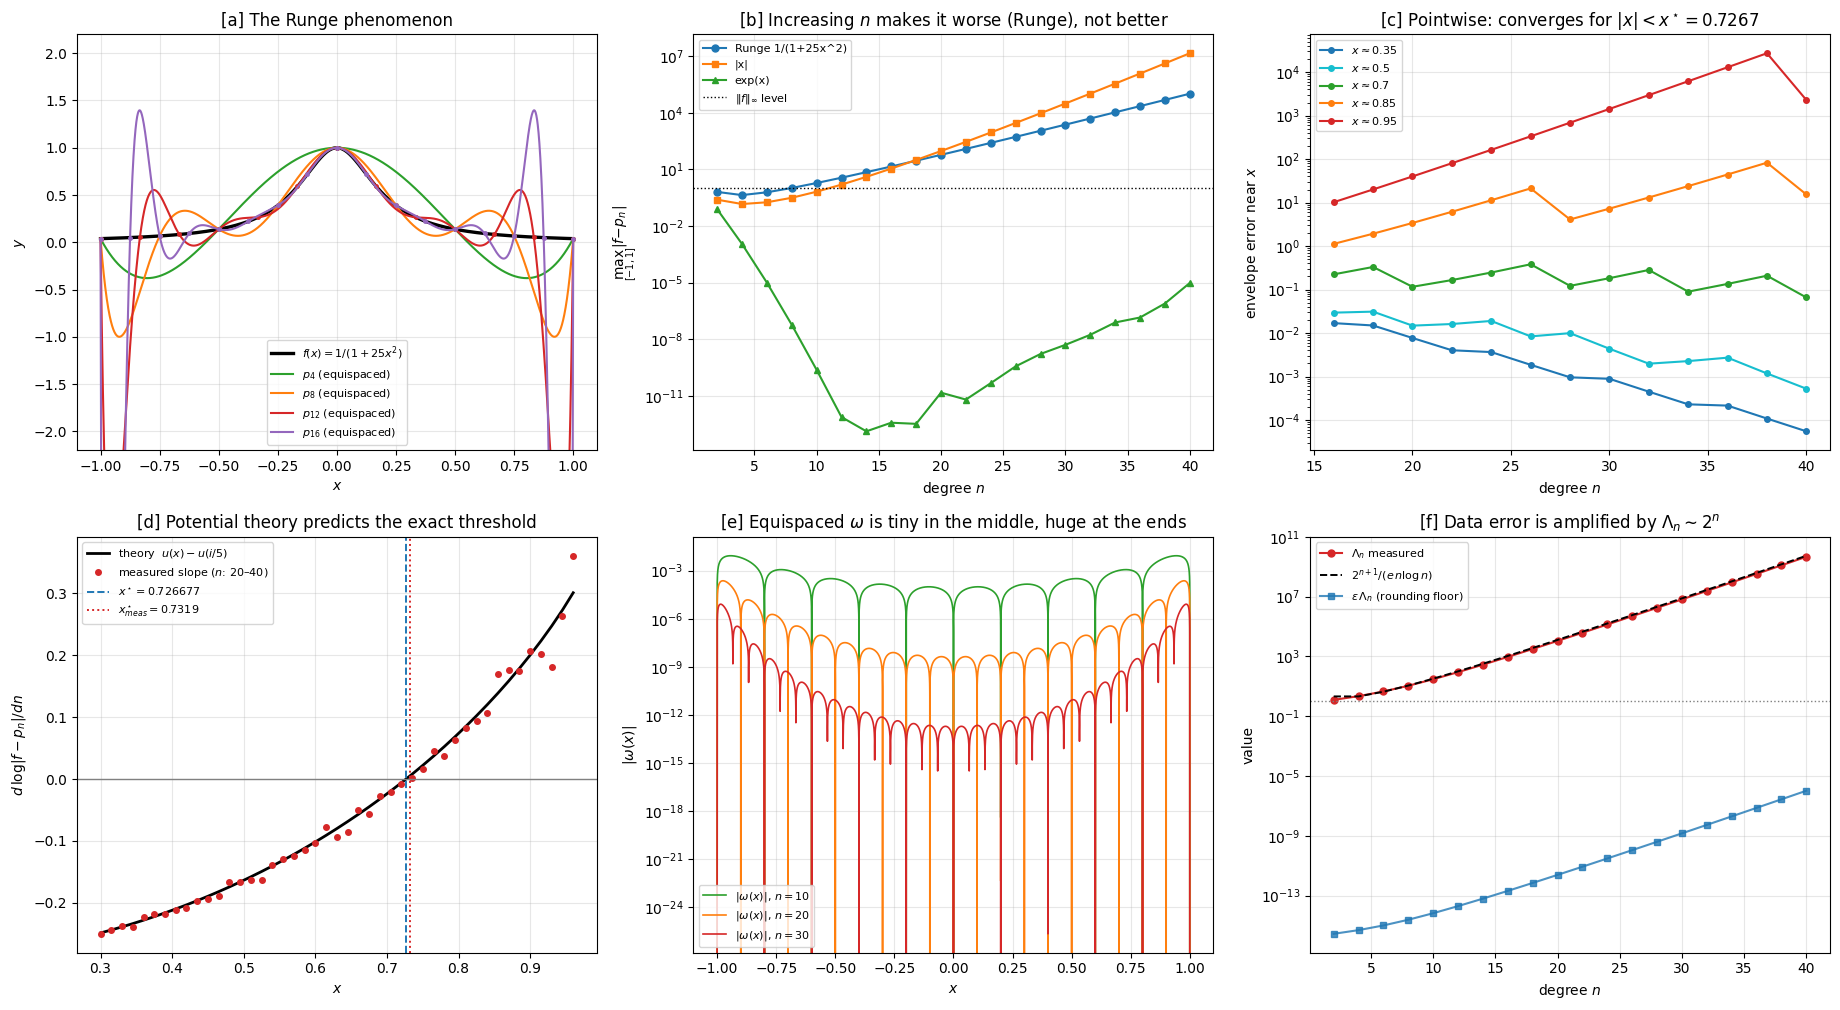

요약
  · 최대오차 : Runge n=40 에서 1.046e+05 — 최소값(n=4)의 2.39e+05 배
  · 임계점   : 이론 0.726677  vs  실측 0.731878  (상대차 0.72 %)
  · 기울기   : 측정 대 이론 상관 r = +0.99481
  · omega    : n=40 에서 끝 봉우리 / 중앙 봉우리 = 3.515e+10
  · Lambda   : n=40 에서 4.692e+09, 점근식 대비 비 0.856


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 3, figsize=(18.5, 10.2))

# [a] Runge 보간
A = ax[0, 0]
A.plot(xd, f_runge(xd), "k-", lw=2.4, label=r"$f(x)=1/(1+25x^2)$")
for n, col in zip([4, 8, 12, 16], ["tab:green", "tab:orange", "tab:red", "tab:purple"]):
    p, xn = interp_equi(f_runge, n, xd)
    A.plot(xd, p, lw=1.5, color=col, label=f"$p_{{{n}}}$ (equispaced)")
    A.plot(xn, f_runge(xn), ".", color=col, ms=5)
A.set_ylim(-2.2, 2.2); A.set_xlabel("$x$"); A.set_ylabel("$y$")
A.set_title("[a] The Runge phenomenon"); A.legend(fontsize=8); A.grid(alpha=.3)

# [b] 최대오차 vs n
B = ax[0, 1]
for name, mk in zip(E.columns, ["o", "s", "^"]):
    B.semilogy(E.index, E[name], marker=mk, ms=5, label=name)
B.axhline(1.0, color="k", ls=":", lw=1, label=r"$\|f\|_\infty$ level")
B.set_xlabel("degree $n$"); B.set_ylabel(r"$\max_{[-1,1]}|f-p_n|$")
B.set_title("[b] Increasing $n$ makes it worse (Runge), not better")
B.legend(fontsize=8); B.grid(alpha=.3)

# [c] 점별 오차 vs n
C = ax[0, 2]
for xv, col in zip([0.35, 0.50, 0.70, 0.85, 0.95],
                   ["tab:blue","tab:cyan","tab:green","tab:orange","tab:red"]):
    ee = [envelope_err(f_runge, n, np.array([xv]))[0][0] for n in ns_fit]
    C.semilogy(ns_fit, np.maximum(ee, 1e-18), "o-", ms=4, color=col, label=f"$x\\approx{xv}$")
C.set_xlabel("degree $n$"); C.set_ylabel("envelope error near $x$")
C.set_title(fr"[c] Pointwise: converges for $|x|<x^\star={x_star:.4f}$")
C.legend(fontsize=8); C.grid(alpha=.3)

# [d] 수렴률 : 측정 vs 이론
D = ax[1, 0]
D.plot(xs_probe, slope_theo, "k-", lw=2, label=r"theory  $u(x)-u(i/5)$")
D.plot(xs_probe, slope_meas, "o", ms=4, color="tab:red", label="measured slope ($n$: 20–40)")
D.axhline(0, color="gray", lw=1)
D.axvline(x_star, color="tab:blue", ls="--", lw=1.4, label=fr"$x^\star={x_star:.6f}$")
D.axvline(x_star_meas, color="tab:red", ls=":", lw=1.4,
          label=fr"$x^\star_{{meas}}={x_star_meas:.4f}$")
D.set_xlabel("$x$"); D.set_ylabel(r"$d\,\log|f-p_n| / dn$")
D.set_title("[d] Potential theory predicts the exact threshold")
D.legend(fontsize=8); D.grid(alpha=.3)

# [e] |omega| 프로파일
Ex = ax[1, 1]
xw = np.linspace(-1, 1, 20001)
for n, col in zip([10, 20, 30], ["tab:green", "tab:orange", "tab:red"]):
    xn = np.linspace(-1, 1, n+1)
    Ex.semilogy(xw, np.exp(log_abs_omega(xn, xw)), color=col, lw=1.2,
                label=fr"$|\omega(x)|$, $n={n}$")
Ex.set_xlabel("$x$"); Ex.set_ylabel(r"$|\omega(x)|$")
Ex.set_title(r"[e] Equispaced $\omega$ is tiny in the middle, huge at the ends")
Ex.legend(fontsize=8); Ex.grid(alpha=.3)

# [f] Lebesgue 상수
F = ax[1, 2]
F.semilogy(L.n, L.Lambda, "o-", ms=5, color="tab:red", label=r"$\Lambda_n$ measured")
F.semilogy(L.n, L.asymptotic, "k--", lw=1.4, label=r"$2^{n+1}/(e\,n\log n)$")
F.semilogy(L.n, L.eps_Lambda, "s-", ms=4, color="tab:blue", alpha=.8,
           label=r"$\varepsilon\,\Lambda_n$ (rounding floor)")
F.axhline(1.0, color="gray", lw=1, ls=":")
F.set_xlabel("degree $n$"); F.set_ylabel("value")
F.set_title("[f] Data error is amplified by $\\Lambda_n \\sim 2^n$")
F.legend(fontsize=8); F.grid(alpha=.3)

plt.tight_layout(); plt.show()

print("요약")
print(f"  · 최대오차 : Runge n=40 에서 {E['Runge 1/(1+25x^2)'].iloc[-1]:.3e}"
      f" — 최소값(n={E['Runge 1/(1+25x^2)'].idxmin()})의 "
      f"{E['Runge 1/(1+25x^2)'].iloc[-1]/E['Runge 1/(1+25x^2)'].min():.3g} 배")
print(f"  · 임계점   : 이론 {x_star:.6f}  vs  실측 {x_star_meas:.6f}"
      f"  (상대차 {abs(x_star_meas-x_star)/x_star*100:.2f} %)")
print(f"  · 기울기   : 측정 대 이론 상관 r = {np.corrcoef(slope_meas, slope_theo)[0,1]:+.5f}")
print(f"  · omega    : n=40 에서 끝 봉우리 / 중앙 봉우리 = {W.ratio_end_center.iloc[-1]:.3e}")
print(f"  · Lambda   : n=40 에서 {L[L.n==40].Lambda.iloc[0]:.3e},"
      f" 점근식 대비 비 {L[L.n==40].ratio.iloc[0]:.3f}")


## 4. 결과 해석

1. **[a]·[b] — 현상은 정확히 교재대로 나온다.** $n$ 을 올릴수록 Runge 함수의 등간격 보간은
   구간 중앙에서는 좋아지고 **양 끝에서 진동이 커진다.** 최대오차는 $n=4$ 에서 최소
   ($4.4\times10^{-1}$) 를 지난 뒤 단조 증가해 $n=14$ 에서 이미 $\|f\|_\infty=1$ 을 넘고
   $n=40$ 에서 $1.05\times10^{5}$ 에 이른다 — **보간다항식이 보간하려는 함수보다 다섯 자리
   크다.** 증가율은 차수당 $1.457$ 배로 안정적이다. 이것이 "차수를 올리면 좋아진다" 는 직관이
   틀리는 표준 반례다.

2. **대조군이 원인을 좁혀 준다.** $e^{x}$ 는 같은 등간격 절점에서 $n=14$ 에 $1.3\times10^{-13}$
   까지 내려간다 — 따라서 **등간격 절점 자체가 문제인 것은 아니다.** ($n\ge 20$ 에서 다시
   올라가는 가지는 절단오차가 아니라 반올림이다: [4] 에서 $\text{err}/\varepsilon\Lambda_n$ 의
   기하평균이 $3.6$ 으로, 같은 자릿수임을 확인했다. 즉 $e^{x}$ 곡선은 **U 자**이고 왼쪽 가지는
   근사이론, 오른쪽 가지는 부동소수점이다.) $|x|$ 는 무한히 매끄럽지 않아서 발산한다.
   Runge 함수는 실축에서는 $C^\infty$ 인데도 발산한다 — 따라서 **실축의 매끄러움도 답이 아니다.**
   세 경우를 가르는 유일한 양은 **복소평면에서 가장 가까운 특이점의 위치**다:
   $e^{x}$ 는 없음($\infty$), Runge 는 $\pm i/5$, $|x|$ 는 실축 위 $0$.

3. **[d] 가 이 노트북의 핵심 결과다.** 퍼텐셜 이론은 오차가
   $\exp[n(u(x)-u(i/5))]$ 처럼 거동한다고 예측하고, 이는 **위치마다 다른 수렴률**을 하나의 곡선으로
   준다. 측정한 기울기 (각 $x$ 에서 중점 포락선 오차의 $\log$ 를 $n$ 에 적합) 는 이 곡선과
   **상관 $r=+0.9948$, 최대 절대차 $0.067$** 로 겹친다. 부호가 바뀌는 지점 — 수렴이 발산으로
   바뀌는 임계점 — 은 실측 $x^\star_{\text{meas}}=0.7319$ 로, 이론
   $x^\star=0.7266768605\ldots$ 와 **상대차 $0.72\,\%$** 다.
   (남은 차이는 유한한 $n$ 의 전점근 효과와, 목표 $x$ 를 가장 가까운 중점으로 스냅한 데서
   오는 최대 $h/2$ 의 위치 편차다 — $n$ 을 키우면 둘 다 줄어든다.)
   **"양 끝에서 나빠진다" 는 정성적 서술이 아니라 소수점까지 계산되는 정량적 사실이다.**

4. **[e] 가 오차식의 첫 인자를 그림으로 보여 준다.** 등간격 절점의 $|\omega(x)|$ 는 중앙에서
   작고 끝 구간에서 수천~수만 배 크다 (표의 `ratio_end_center`). 절점은 균등하게 놓았는데
   **절점다항식은 전혀 균등하지 않다** — 이 비대칭이 Runge 현상의 기하학적 정체다.
   Problem 3 은 바로 이 $|\omega|$ 를 평평하게 만드는 절점 배치를 찾는다.

5. **두 번째 인자는 함수 쪽이다.** Cauchy 상계 $M_r/r^{\,n+1}$ 은 $r<1/5$ 여야 하므로
   $5^{\,n}$ 규모로 커진다. 표의 `product_bound` 는 이 둘의 곱이고 $n$ 과 함께 폭발한다.
   **다만 이것은 상계이므로 실제 오차보다 훨씬 크다** — 여기서 읽어야 할 것은 값이 아니라
   *증가한다는 사실*이며, 위치별 정밀한 판정은 3 항의 퍼텐셜 논증이 한다.

6. **[f] — Lebesgue 상수가 세 번째 층을 더한다.** 측정한 $\Lambda_n$ 은 Turetskii 점근식
   $2^{n+1}/(e\,n\log n)$ 과 비가 $0.85$ 근처에서 안정되고, $\log_2\Lambda_n$ 의 기울기가
   $0.94$ (이론 $1$ = 차수당 2 배) 다. 비가 정확히 $1$ 이 아닌 것은 점근식이 $n\to\infty$ 에서만
   성립하고 $\log n$ 항의 수렴이 매우 느리기 때문이다 — 확인되는 것은 **지수 $2^n$** 이지
   상수가 아니다. 함의가 셋이다. (i) Lebesgue 부등식 $\|f-p_n\|\le(1+\Lambda_n)E_n(f)$ 에서, 최선근사가
   아무리 좋아도 $\Lambda_n$ 이 $2^n$ 이면 보간은 따라가지 못한다. (ii) 자료에 $\delta$ 의 잡음이
   있으면 보간은 $2^n\delta$ 만큼 흔들린다 — **측정값 보간에 고차 등간격 다항식을 쓰면 안 되는
   이유**다. (iii) 잡음이 반올림뿐이어도 $\varepsilon\Lambda_n$ 이 $n=34$ 에서 이미
   $10^{-8}$ 을 넘는다. **Problem 1 [a] 의 등간격 곡선이 바로 이것이었다** — 그때는 정체를
   몰랐고, 이제 이름이 붙었다.

> **결론**: Runge 현상은 알고리즘의 결함이 아니다. 세 층이 **전부 절점 배치에서 나온다** —
> $|\omega|$ 가 끝으로 몰리고, 그것이 복소 특이점까지의 거리와 겨루며, 그 위에 $\Lambda_n\sim 2^n$
> 이 자료 오차를 증폭한다. 형식을 아무리 잘 골라도 (Problem 1 에서 무게중심을 썼다) 고칠 수 없다.

**다음 문제로의 연결** — 고칠 수 있는 것은 하나뿐이다: **절점을 옮기는 것.** Problem 3 은
$\|\omega\|_\infty$ 를 최소화하는 절점 — Chebyshev 절점 — 이 $\|\omega\|_\infty=2^{-n}$ 을
달성하고 $\Lambda_n$ 을 $2^n$ 에서 $\tfrac{2}{\pi}\log n$ 으로 끌어내린다는 것을 확인한다.